## Import libraries

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from scipy.signal import savgol_filter
import os

from unityvr.preproc import logproc
from unityvr.viz import viz

#from sys import path
from os.path import sep, exists
from os import mkdir, makedirs, getcwd

# import pycircstat

## Data file

In [206]:
rootDir = '/Volumes/otopaliklab/Temporary_Storage/Aisha/BehaviorData'
flyID = 'Fly10'
trial_folder = 'I'

In [207]:
dataDir = os.path.join(rootDir, 'raw', flyID, trial_folder)
preprocDir = os.path.join(rootDir, 'preproc', flyID, trial_folder)
plotDir = os.path.join(rootDir, 'plot', flyID, trial_folder)

# Make directories if they don't exist
os.makedirs(preprocDir, exist_ok=True)
os.makedirs(plotDir, exist_ok=True)

In [208]:
dirName = dataDir
fileName = "Log_2025-09-25_20-13-41_Fly10I.json"

dat = logproc.openUnityLog(dirName, fileName)

for i in range(5):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "headerNotes": "darkspot-20degspot-fh- 125degpersec-120fps- anglerange90deg panWidth_px-1504-panHeight_px-582 Fly10I RED ON 30sec ON, 5sec OFF 20% duty cycle, 10 Hz                                                                                                                                                                                                                                          ",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.04500000178813934,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "fr

### Construct data object from log file

In [209]:
logproc.makeMetaDict(dat, fileName)

{'expid': 'testExp',
 'experiment': 'test experiment',
 'genotype': 'testGenotype',
 'sex': 'NA',
 'flyid': 'NA',
 'trial': 'trially10I',
 'date': '2025-09-25',
 'time': '20-13-41',
 'ballRad': 0.04500000178813934,
 'translationalGain': 1.0,
 'setFrameRate': 120,
 'notes': 'NA',
 'temperature': 'NA',
 'angle_convention': 'right-handed'}

In [210]:
objDf = logproc.objDfFromLog(dat)
objDf.head()

,name,collider,px,py,pz,rx,ry,rz,sx,sy,sz
0,Fly/FlyCamera4/FlyCamera4Screen,MeshCollider,-1.233444,-3.796151,0.01,0.0,0.0,18.000004,5.800001,1.0,9.5
1,Fly/FlyCamera1/FlyCamera1Screen,MeshCollider,-1.233444,3.79615,0.01,0.0,0.0,162.0,5.8,1.0,9.5
2,Fly/FlyCamera2/FlyCamera2Screen,MeshCollider,3.229198,2.34615,0.01,0.0,0.0,234.0,5.800001,1.0,9.5
3,Fly/FlyCamera3/FlyCamera3Screen,MeshCollider,3.229198,-2.346149,0.01,0.0,0.0,306.0,5.8,1.0,9.5
4,BackgroundCylinder/default,NA,0.0,0.0,-0.5,0.0,0.0,90.0,-3.992001,3.992001,4.75


In [211]:
posDf, ftDf, tsDf = logproc.timeseriesDfFromLog(dat)

correcting for Unity angle convention.


In [212]:
# Extract ball radius
matching = [s for s in dat if "ficTracBallRadius" in s]
ballRadius = matching[0]["ficTracBallRadius"]
print(ballRadius) # in decimeters

#conversion factor to cm
dc2cm = 10

0.04500000178813934


### Import stimulus data---stimulus angular position

In [213]:
# Import stimulus angle data
## All decimal points (more precise for stimulus speed measurements)
from decimal import Decimal, getcontext, ROUND_HALF_UP
getcontext().prec = 50  # enough precision (>20 dp)

# Read as strings first so nothing is rounded
df = pd.read_csv('/Volumes/otopaliklab/Temporary_Storage/Aisha/UnityProtocols/new2_fh_3.1_6.5/darkspot-20degspot-fh-125degpersec-120fps-anglerange90deg--panWidth_px-1504-panHeight_px-582/imageDf.csv', dtype=str)

# Convert selected columns to Decimal (exact)
for col in ['time [s]', 'angular_shift (deg)']:
    df[col] = df[col].map(Decimal)

# Show full precision (Decimal prints all digits)
print(df.head().to_string(index=False))

frame             time [s] filename shifts (px) angular_shift (deg)
    1                  0.0    1.png        -188               -45.0
    2 0.008372093023255813    2.png        -184  -43.95348837209302
    3 0.016744186046511626    3.png        -179 -42.906976744186046
    4  0.02511627906976744    4.png        -175 -41.860465116279066
    5  0.03348837209302325    5.png        -171  -40.81395348837209


### Create a stimulus time series

In [214]:
# Copy original stimulus df
stimulus_df = df.copy()

# Total duration of one stimulus cycle
stimulus_duration = stimulus_df['time [s]'].max()

# Total duration of tracking data
total_duration = Decimal(str(posDf['time'].max()))  # Convert float to Decimal safely

# How many full repeats of the stimulus are needed
num_repeats = int((total_duration / stimulus_duration).to_integral_value(rounding=ROUND_HALF_UP)) + 1

# Repeat and shift time
repeated_stimulus_dfs = []

for i in range(num_repeats):
    temp = stimulus_df.copy()
    time_offset = stimulus_duration * i
    temp['time [s]'] = temp['time [s]'].apply(lambda t: t + time_offset)
    repeated_stimulus_dfs.append(temp)

# Combine all repeats
repeated_df = pd.concat(repeated_stimulus_dfs, ignore_index=True)

# Trim to match posDf time range
repeated_df = repeated_df[repeated_df['time [s]'] <= total_duration]

# Remove duplicate time values if any
repeated_df = repeated_df[~repeated_df['time [s]'].duplicated()]

### Circstat_fly heading angle

In [215]:
# normalize fly heading angle to [-180, 180)
def normalize_angle_deg(angle_deg):
    return ((angle_deg + 180) % 360) - 180

# circular difference
def circ_dist_deg(x, y):
    return normalize_angle_deg(x - y)

# Extract arrays
pos_time = posDf['time'].to_numpy()
pos_angle = posDf['angle'].to_numpy()
pos_angle = normalize_angle_deg(pos_angle)

# Frame-to-frame circular differences
delta_angle_pos = circ_dist_deg(pos_angle[1:], pos_angle[:-1])
delta_time_pos = pos_time[1:] - pos_time[:-1]
angular_velocity_pos = delta_angle_pos / delta_time_pos  # deg/sec

# Store in DataFrame
angular_velocity_df = pd.DataFrame({
    'time': pos_time[1:],  # skip first
    'angular_velocity_dps': angular_velocity_pos
})

### Circstat_stimulus angle

In [216]:
# normalize Decimal angle
def normalize_angle_deg_decimal(angle_deg):
    return ((angle_deg + Decimal(180)) % Decimal(360)) - Decimal(180)

# circular difference
def circ_dist_deg_decimal(x, y):
    return normalize_angle_deg_decimal(x - y)

# Extract angle/time as Decimal lists
stim_time = repeated_df['time [s]'].tolist()
stim_angle = repeated_df['angular_shift (deg)'].tolist()

# Frame-to-frame circular diffs
delta_angle_stim = [circ_dist_deg_decimal(stim_angle[i], stim_angle[i-1]) for i in range(1, len(stim_angle))]
delta_time_stim = [stim_time[i] - stim_time[i-1] for i in range(1, len(stim_time))]
angular_velocity_stim = [da / dt for da, dt in zip(delta_angle_stim, delta_time_stim)]

# Store in DataFrame (convert Decimal to float for plotting)
stimulus_velocity_df = pd.DataFrame({
    'time': [float(t) for t in stim_time[1:]],
    'angular_velocity_dps': [float(v) for v in angular_velocity_stim]
})

In [217]:
print("posDf angular velocity shape:", angular_velocity_df.shape)
print("stimulus angular velocity shape:", stimulus_velocity_df.shape)

posDf angular velocity shape: (15743, 2)
stimulus angular velocity shape: (17220, 2)


#### Interpolate stimulus velocity to match time in posDf

In [218]:
# X-axis for both plots: posDf time (after first frame)
plot_time = angular_velocity_df['time'].to_numpy()  

# Interpolation inputs from stimulus velocity
stim_time = stimulus_velocity_df['time'].to_numpy()                  
stim_vel = stimulus_velocity_df['angular_velocity_dps'].to_numpy()  

# Interpolate stimulus velocity to match posDf time
stim_vel_interp = np.interp(plot_time, stim_time, stim_vel)  

#### Plot

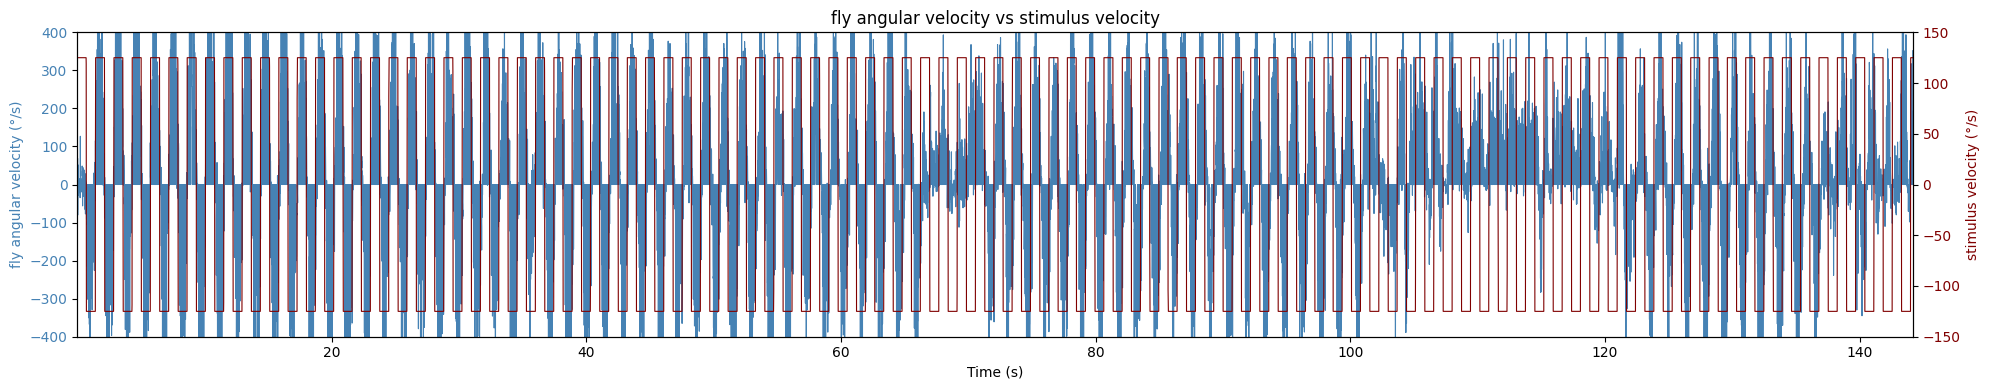

In [219]:
fig, ax1 = plt.subplots(figsize=(20, 4))

# Left Y-axis: Positional angular velocity (raw or smoothed)
ln1 = ax1.plot(
    plot_time,
    angular_velocity_df['angular_velocity_dps'],  # Or use 'angular_velocity_dps' for raw
    label='Fly Angular Velocity (Smoothed)',
    color='steelblue',
    linewidth=0.8
)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("fly angular velocity (°/s)", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(-400, 400)
ax1.set_xlim([plot_time[0], plot_time[-1]])
ax1.grid(False)

# Right Y-axis: Stimulus angular velocity
ax2 = ax1.twinx()

ln2 = ax2.plot(
    plot_time,
    stim_vel_interp,
    label='stimulus velocity',
    color='maroon',
    linewidth=0.8
)

ax2.set_ylabel("stimulus velocity (°/s)", color='maroon')
ax2.tick_params(axis='y', labelcolor='maroon')
ax2.set_ylim(-150, 150)

# # Combine both line objects for legend
# lines = ln1 + ln2
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper right')

# Title and display
ax1.set_title("fly angular velocity vs stimulus velocity")
plt.tight_layout()
plt.show()

### Filter the angular velocity

In [220]:
from scipy.signal import savgol_filter

dt = np.median(np.diff(angular_velocity_df['time']))
window_sec = 0.2
window_length = int(np.ceil(window_sec / dt))

polyorder = 5
if window_length % 2 == 0:
    window_length += 1
    
window_length = max(window_length, polyorder + 2 + (polyorder + 2) % 2)

print(f"Using window length: {window_length} samples ({window_length * dt:.4f} s)")



Using window length: 25 samples (0.2083 s)


In [221]:
# Apply filter to positional angular velocity
angular_velocity_smoothed = savgol_filter(
    angular_velocity_df['angular_velocity_dps'].to_numpy(),
    window_length=window_length,
    polyorder=polyorder
)

# Add to DataFrame
angular_velocity_df['smoothed_dps'] = angular_velocity_smoothed

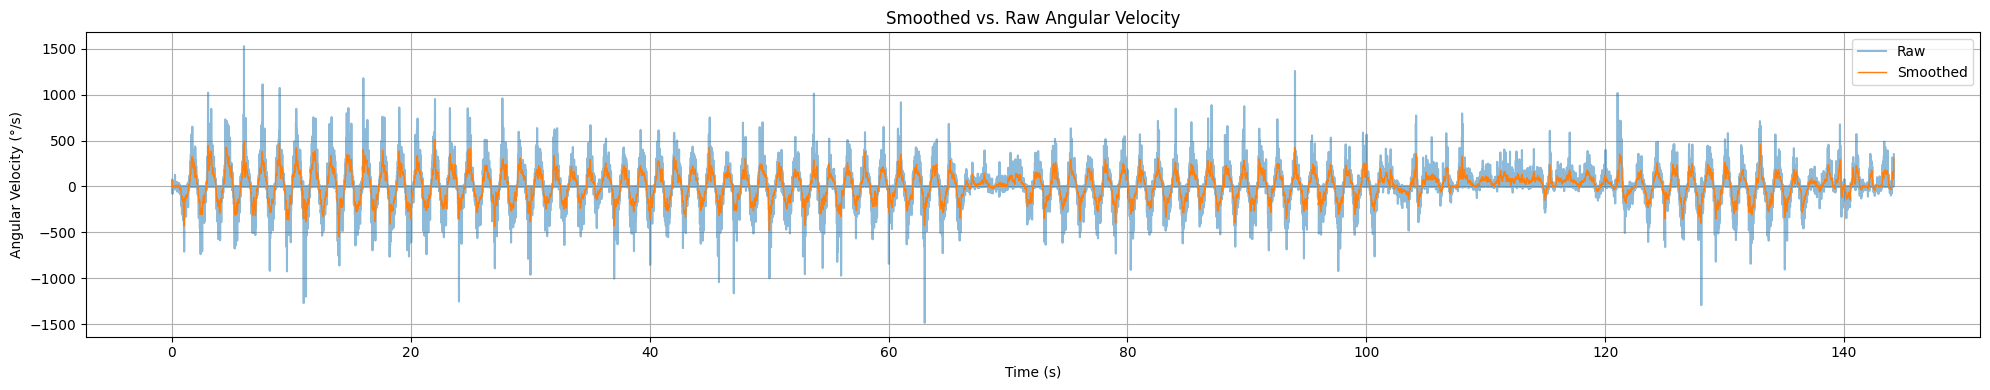

In [222]:
plt.figure(figsize=(20, 4))
plt.plot(angular_velocity_df['time'], angular_velocity_df['angular_velocity_dps'], label='Raw', alpha=0.5)
plt.plot(angular_velocity_df['time'], angular_velocity_df['smoothed_dps'], label='Smoothed', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (°/s)")
# plt.ylim(-400, 400)
plt.title("Smoothed vs. Raw Angular Velocity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Plot smoothed data and stimulus velocity

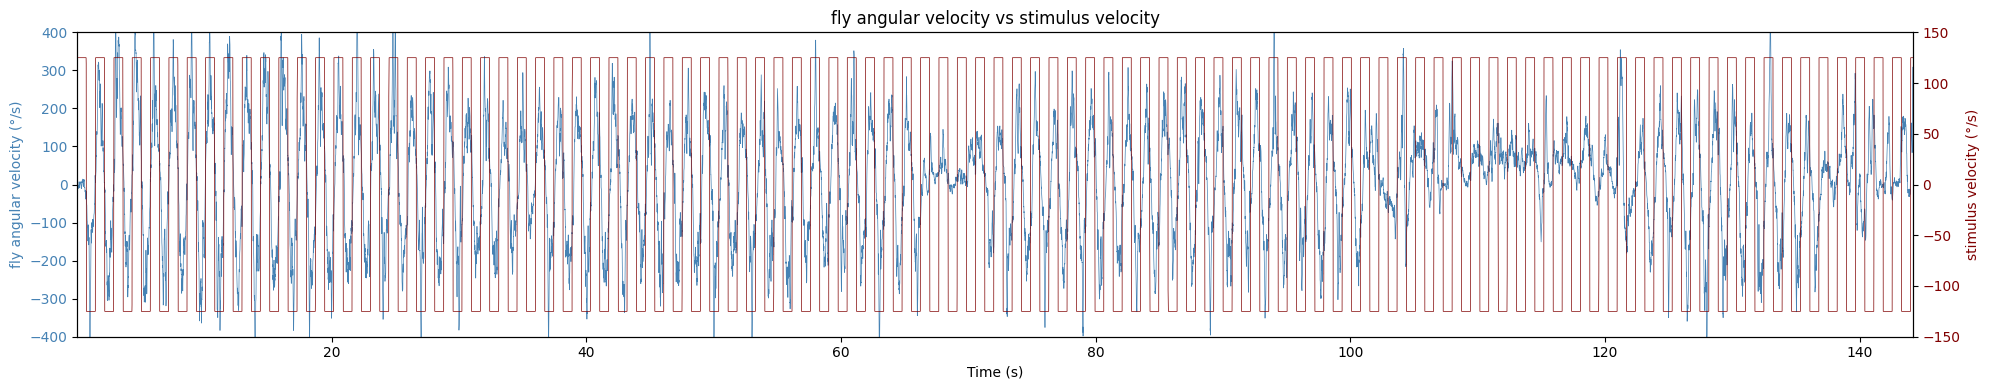

In [223]:
fig, ax1 = plt.subplots(figsize=(20, 4))

# Left Y-axis: Smoothed positional angular velocity
ax1.plot(
    plot_time,
    angular_velocity_df['smoothed_dps'],  # <-- smoothed data
    label='fly angular velocity',
    color='steelblue',
    linewidth=0.5
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("fly angular velocity (°/s)", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(-400, 400)

# X-axis full range
ax1.set_xlim([plot_time[0], plot_time[-1]])

# Right Y-axis: Stimulus angular velocity
ax2 = ax1.twinx()
ax2.plot(
    plot_time,
    stim_vel_interp,
    label='Stimulus Velocity',
    color='maroon',
    linewidth=0.5
)
ax2.set_ylabel("stimulus velocity (°/s)", color='maroon')
ax2.tick_params(axis='y', labelcolor='maroon')
ax2.set_ylim(-150, 150)

# Finalize
plt.title("fly angular velocity vs stimulus velocity")
ax1.grid(False)
plt.tight_layout()
plt.show()

### LED signal

In [224]:
# --- Parameters ---
threshold = 5           # LED ON threshold (actual signal is -10 to 10)
max_off_gap = 2.0       # Max gap between ON pulses to merge into one ON block

# --- Extract LED signal and time ---
ledsig = tsDf['ledsig'].values
led_time = tsDf['time'].values

# --- Detect raw ON pulses ---
led_on = ledsig > threshold
transitions = np.diff(led_on.astype(int))
starts = led_time[:-1][transitions == 1]
ends   = led_time[:-1][transitions == -1]

# --- Edge case handling ---
if led_on[0]:
    starts = np.insert(starts, 0, led_time[0])
if led_on[-1]:
    ends = np.append(ends, led_time[-1])


# --- Merge nearby ON pulses into ON blocks ---
if len(starts) == 0 or len(ends) == 0:
    merged_starts = np.array([])
    merged_ends = np.array([])
else:
    # Proceed with merging logic
    merged_starts = []
    merged_ends = []

    current_start = starts[0]
    current_end = ends[0]

    for i in range(1, len(starts)):
        gap = starts[i] - current_end
        if gap <= max_off_gap:
            current_end = ends[i]
        else:
            merged_starts.append(current_start)
            merged_ends.append(current_end)
            current_start = starts[i]
            current_end = ends[i]

    merged_starts.append(current_start)
    merged_ends.append(current_end)

    merged_starts = np.array(merged_starts)
    merged_ends = np.array(merged_ends)

# --- Build full ON/OFF periods ---
periods = []
current_time = led_time[0]

for start, end in zip(merged_starts, merged_ends):
    if start > current_time:
        periods.append((current_time, start, 'OFF'))
    periods.append((start, end, 'ON'))
    current_time = end

if current_time < led_time[-1]:
    periods.append((current_time, led_time[-1], 'OFF'))

# --- Print final ON/OFF periods ---
for start, end, state in periods:
    print(f"{start:.2f}–{end:.2f}  {state}")

0.00–0.03  OFF
0.03–29.99  ON
29.99–35.06  OFF
35.06–64.98  ON
64.98–70.07  OFF
70.07–99.99  ON
99.99–105.07  OFF
105.07–134.98  ON
134.98–140.06  OFF
140.06–144.10  ON
144.10–144.17  OFF


In [225]:
on_start_times = merged_starts
on_end_times = merged_ends

### Plot with LED signal

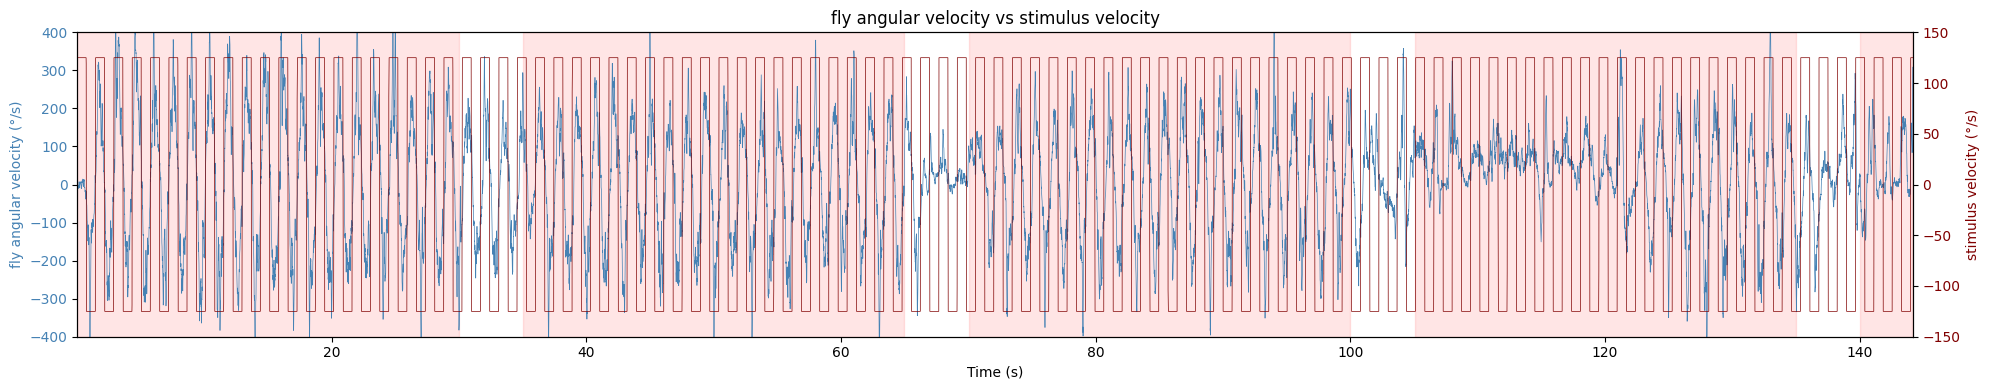

In [226]:
fig, ax1 = plt.subplots(figsize=(20, 4))

# Left Y-axis: Smoothed positional angular velocity
ax1.plot(
    plot_time,
    angular_velocity_df['smoothed_dps'],  # <-- smoothed data
    label='fly angular velocity',
    color='steelblue',
    linewidth=0.5
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("fly angular velocity (°/s)", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(-400, 400)

# X-axis full range
ax1.set_xlim([plot_time[0], plot_time[-1]])

# Right Y-axis: Stimulus angular velocity
ax2 = ax1.twinx()
ax2.plot(
    plot_time,
    stim_vel_interp,
    label='Stimulus Velocity',
    color='maroon',
    linewidth=0.5
)
ax2.set_ylabel("stimulus velocity (°/s)", color='maroon')
ax2.tick_params(axis='y', labelcolor='maroon')
ax2.set_ylim(-150, 150)


# --- Add full-height shaded regions for LED ON using detected blocks ---
for i, (start, end) in enumerate(zip(merged_starts, merged_ends)):
    ax1.axvspan(start, end, ymin=0, ymax=1, color='red', alpha=0.1, label='LED ON' if i == 0 else None)
    
    
# Finalize
plt.title("fly angular velocity vs stimulus velocity")
ax1.grid(False)
plt.tight_layout()
plt.show()

## Moving correlation (Fidelity)

In [227]:
# Convert your data into pandas Series (if not already)
fly_vel = pd.Series(angular_velocity_df['smoothed_dps'].to_numpy())
stim_vel = pd.Series(stim_vel_interp)

In [228]:
# Time vector
time = plot_time  # already used your plots

# Define window size in seconds
window_sec = 1.44

# Compute sampling interval and window length in samples
dt = np.mean(np.diff(time))
window_samples = int(np.round(window_sec / dt))

# Ensure it's an odd number for centered window
if window_samples % 2 == 0:
    window_samples += 1

In [190]:
window_samples

149

In [229]:
# Moving Pearson correlation using centered window
moving_corr = fly_vel.rolling(window=window_samples, center=True).corr(stim_vel)

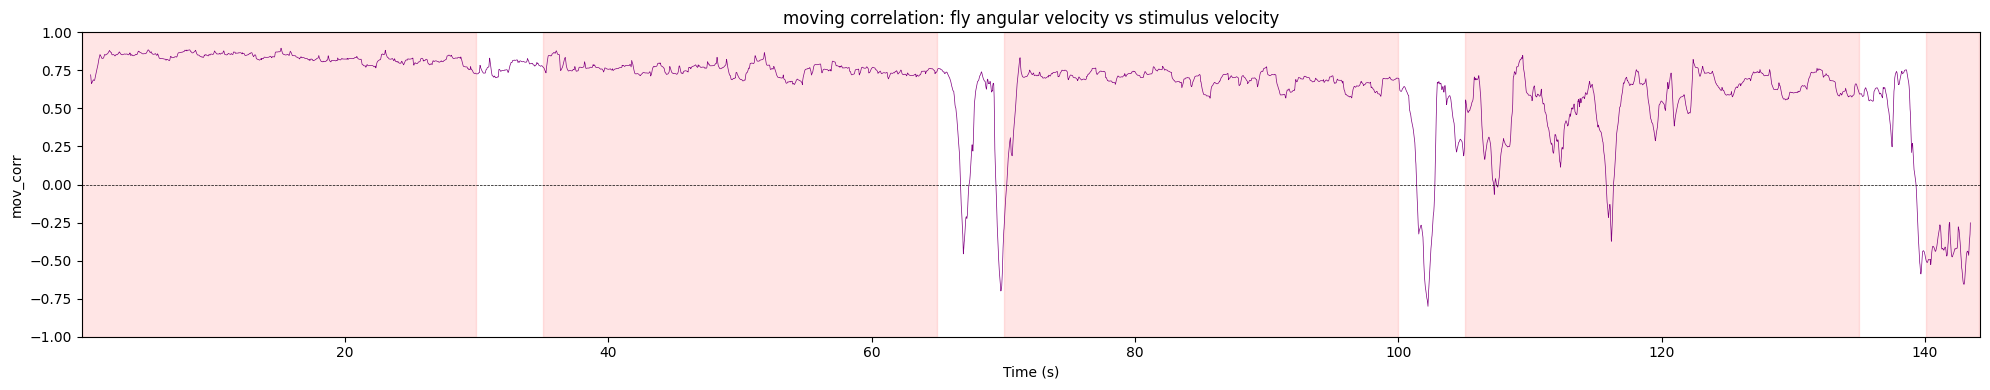

In [230]:
plt.figure(figsize=(20, 4))
plt.plot(time, moving_corr, color='purple', linewidth=0.5, label='Moving Correlation (r)')
plt.xlabel("Time (s)")
plt.ylabel("mov_corr")
plt.title("moving correlation: fly angular velocity vs stimulus velocity")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.ylim(-1, 1)
plt.xlim([time[0], time[-1]])
# plt.xlim(0, 3)

# --- Add full-height shaded regions for LED ON using detected blocks ---
for i, (start, end) in enumerate(zip(merged_starts, merged_ends)):
    plt.axvspan(start, end, ymin=0, ymax=1, color='red', alpha=0.1, label='LED ON' if i == 0 else None)
    
    
plt.grid(False)
plt.tight_layout()
plt.show()

## Vigour of pursuit

In [231]:
vigour = fly_vel.rolling(window=window_samples, center=True).apply(lambda x: x.max() - x.min(), raw=True)

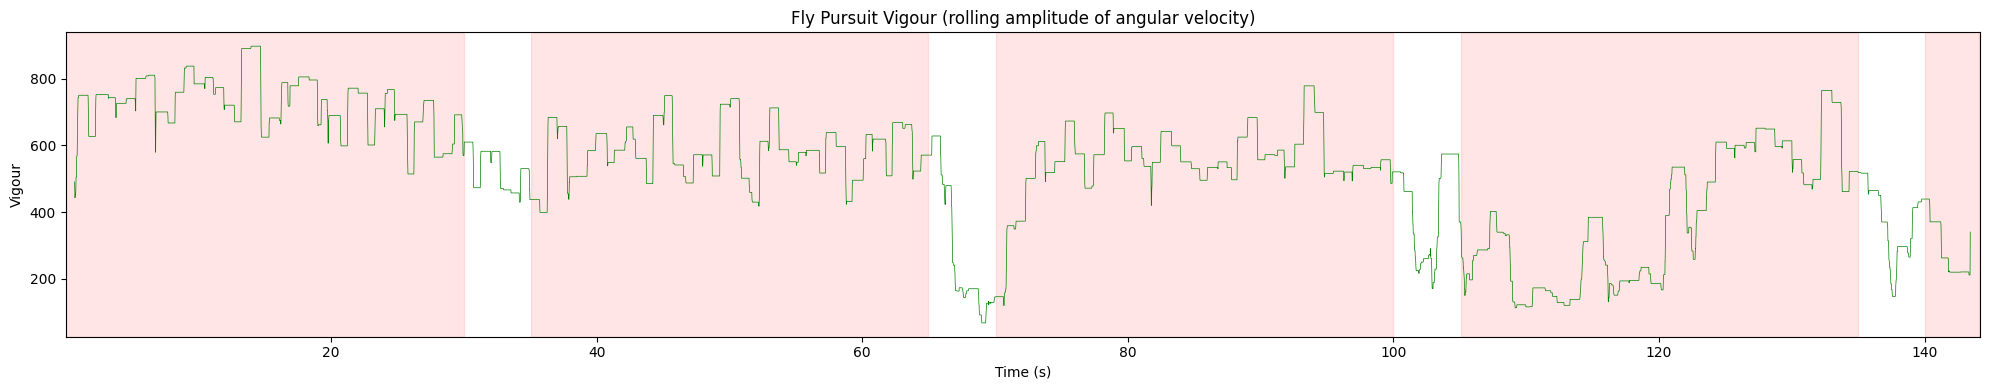

In [232]:
plt.figure(figsize=(20, 4))
plt.plot(time, vigour, color='green', linewidth=0.5, label='Vigour (peak-to-peak)')
plt.xlabel("Time (s)")
plt.ylabel("Vigour")
plt.title("Fly Pursuit Vigour (rolling amplitude of angular velocity)")
plt.xlim([time[0], time[-1]])

for i, (start, end) in enumerate(zip(merged_starts, merged_ends)):
    plt.axvspan(start, end, ymin=0, ymax=1, color='red', alpha=0.1, label='LED ON' if i == 0 else None)

plt.grid(False)
plt.tight_layout()
plt.show()


## Tracking index (fidelity * vigour)

In [233]:
tracking_index = moving_corr * vigour


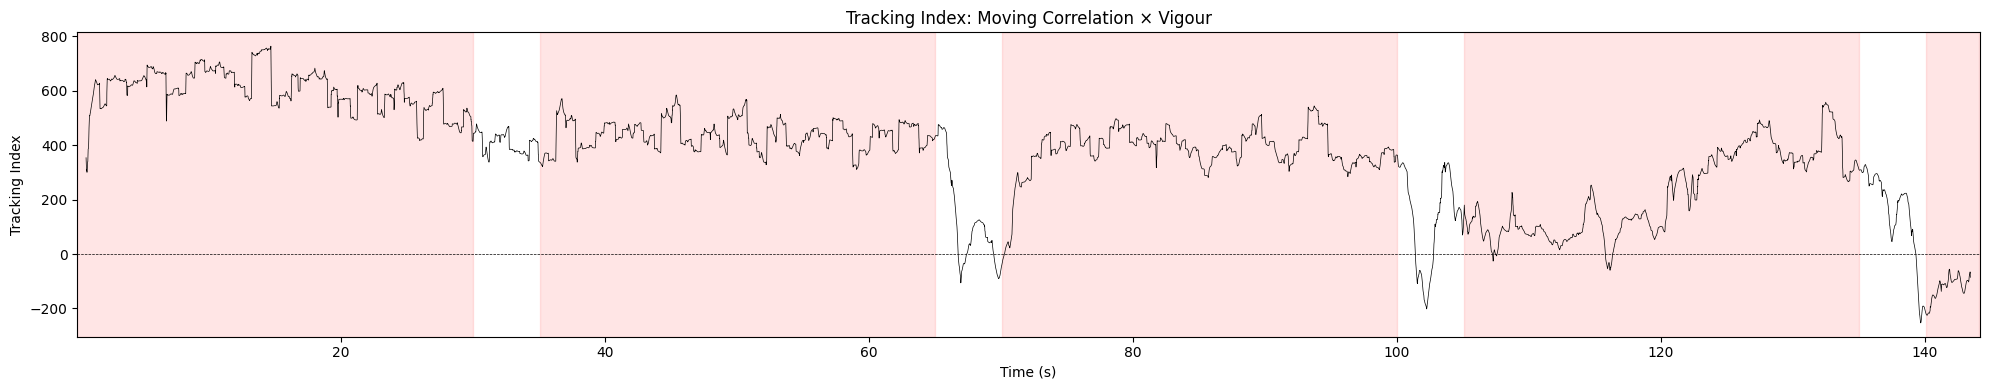

In [234]:
plt.figure(figsize=(20, 4))
plt.plot(time, tracking_index, color='black', linewidth=0.5, label='Tracking Index')
plt.xlabel("Time (s)")
plt.ylabel("Tracking Index")
plt.title("Tracking Index: Moving Correlation × Vigour")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.xlim([time[0], time[-1]])

for i, (start, end) in enumerate(zip(merged_starts, merged_ends)):
    plt.axvspan(start, end, ymin=0, ymax=1, color='red', alpha=0.1, label='LED ON' if i == 0 else None)

plt.grid(False)
plt.tight_layout()
plt.show()


#### Normalize Tracking index

In [235]:
max_abs = np.nanmax(np.abs(tracking_index))
normalized_tracking_index = tracking_index / max_abs

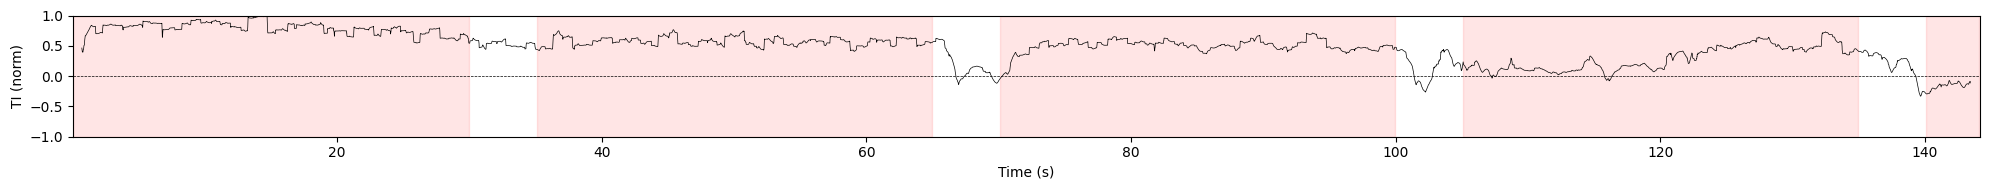

In [236]:
plt.figure(figsize=(20, 2))
plt.plot(time, normalized_tracking_index, color='black', linewidth=0.5, label='Normalized Tracking Index')
plt.xlabel("Time (s)")
plt.ylabel("TI (norm)")
# plt.title("normalized tracking index: (correlation × vigour) ")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.ylim(-1, 1)
plt.xlim([time[0], time[-1]])

for i, (start, end) in enumerate(zip(merged_starts, merged_ends)):
    plt.axvspan(start, end, ymin=0, ymax=1, color='red', alpha=0.1, label='LED ON' if i == 0 else None)

plt.grid(False)
plt.tight_layout()
plt.show()


## Cross correlation

In [69]:
fly_vel = angular_velocity_df['smoothed_dps'].to_numpy()
stim_vel = stim_vel_interp  # already a numpy array

# Compute pointwise tracking index
tracking_index = fly_vel / stim_vel

In [70]:
from scipy.signal import savgol_filter

# Optional smoothing (adjust window as needed)
tracking_index_smoothed = savgol_filter(tracking_index, window_length=31, polyorder=3)

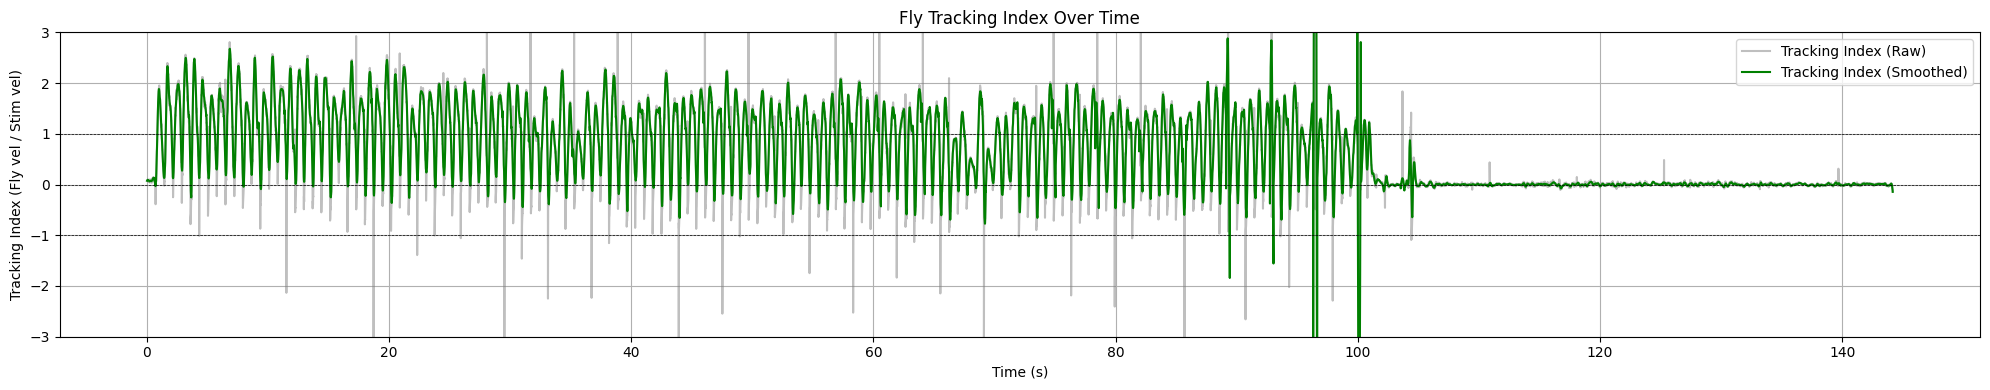

In [72]:
plt.figure(figsize=(20, 4))
plt.plot(plot_time, tracking_index, label='Tracking Index (Raw)', color='gray', alpha=0.5)
plt.plot(plot_time, tracking_index_smoothed, label='Tracking Index (Smoothed)', color='green', linewidth=1.5)
plt.axhline(1, color='black', linestyle='--', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axhline(-1, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Tracking Index (Fly vel / Stim vel)')
plt.ylim(-3, 3)
plt.title('Fly Tracking Index Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cross correlation stimulus angle/fly heading angle

In [30]:
stim_angle = np.array([float(a) for a in stim_angle])
pos_angle = np.array(pos_angle)

In [33]:
stim_time = np.array([float(t) for t in stim_time])
stim_angle = stim_angle[:len(stim_time)]
stim_angle_interp = np.interp(pos_time, stim_time, stim_angle)

In [32]:
print("Length of stim_time:", len(stim_time))
print("Length of stim_angle:", len(stim_angle))

Length of stim_time: 17220
Length of stim_angle: 17221


In [34]:
stim_x = np.cos(np.radians(stim_angle_interp))
stim_y = np.sin(np.radians(stim_angle_interp))

fly_x = np.cos(np.radians(pos_angle))
fly_y = np.sin(np.radians(pos_angle))

In [35]:
stim_x = (stim_x - np.mean(stim_x)) / np.std(stim_x)
stim_y = (stim_y - np.mean(stim_y)) / np.std(stim_y)

fly_x = (fly_x - np.mean(fly_x)) / np.std(fly_x)
fly_y = (fly_y - np.mean(fly_y)) / np.std(fly_y)

In [36]:
from scipy.signal import correlate

corr_x = correlate(fly_x, stim_x, mode='full')
corr_y = correlate(fly_y, stim_y, mode='full')

corr_total = (corr_x + corr_y) / 2

In [41]:
lags = np.arange(-len(fly_x) + 1, len(fly_x))
peak_index = np.argmax(corr_total)
peak_lag = lags[peak_index]

# Convert to time
sampling_rate = 1 / np.median(np.diff(pos_time))
lag_in_seconds = peak_lag / sampling_rate

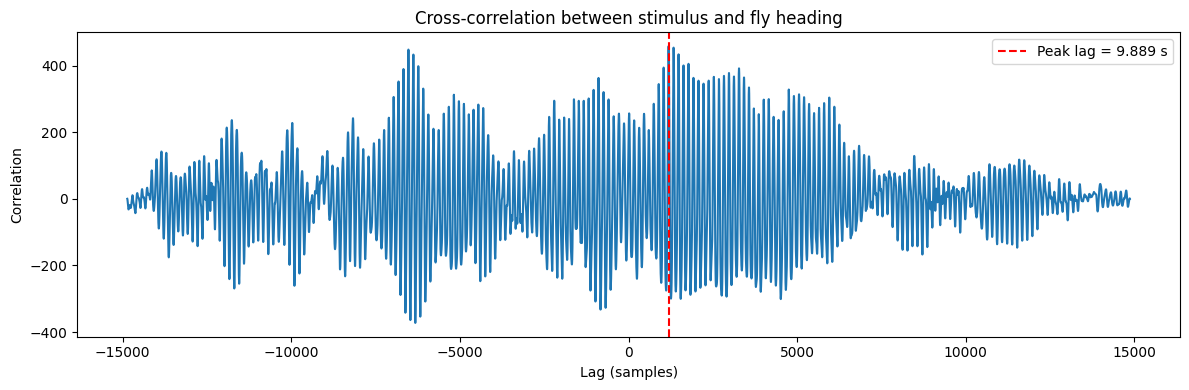

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(lags, corr_total)
plt.axvline(peak_lag, color='red', linestyle='--', label=f'Peak lag = {lag_in_seconds:.3f} s')
plt.xlabel('Lag (samples)')
plt.ylabel('Correlation')
plt.title('Cross-correlation between stimulus and fly heading')
plt.legend()
plt.tight_layout()
plt.show()

### Cross correlation stimulus velocity vs /fly heading velocity

In [44]:
fly_vel = angular_velocity_df['smoothed_dps'].to_numpy()
stim_vel = stim_vel_interp  # already interpolated

In [45]:
fly_vel = (fly_vel - np.mean(fly_vel)) / np.std(fly_vel)
stim_vel = (stim_vel - np.mean(stim_vel)) / np.std(stim_vel)

In [46]:

corr_vel = correlate(fly_vel, stim_vel, mode='full')
lags_vel = np.arange(-len(fly_vel) + 1, len(fly_vel))

In [47]:
peak_index_vel = np.argmax(corr_vel)
peak_lag_vel = lags_vel[peak_index_vel]

sampling_rate = 1 / np.median(np.diff(plot_time))  # same as before
lag_seconds_vel = peak_lag_vel / sampling_rate

print(f"Peak lag: {peak_lag_vel} samples")
print(f"Lag in time: {lag_seconds_vel:.4f} seconds")

Peak lag: 10 samples
Lag in time: 0.0833 seconds


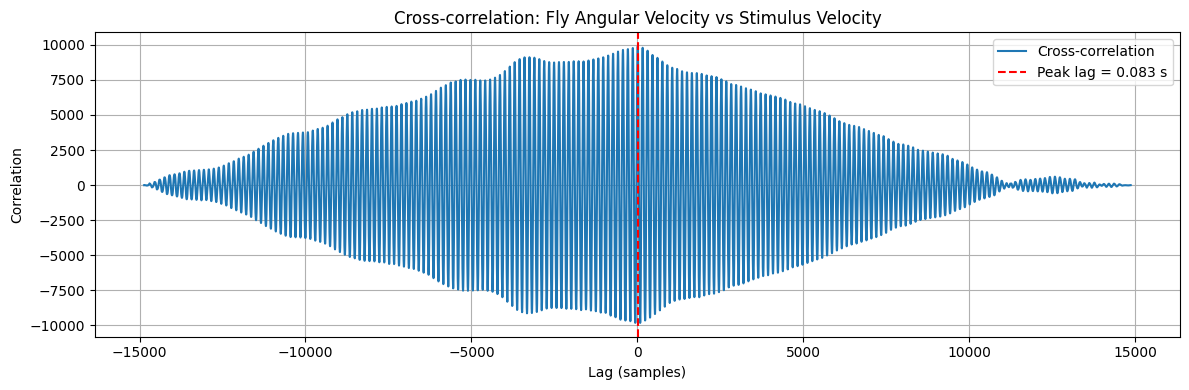

In [48]:
plt.figure(figsize=(12, 4))
plt.plot(lags_vel, corr_vel, label='Cross-correlation')
plt.axvline(peak_lag_vel, color='red', linestyle='--', label=f'Peak lag = {lag_seconds_vel:.3f} s')
plt.xlabel('Lag (samples)')
plt.ylabel('Correlation')
plt.title('Cross-correlation: Fly Angular Velocity vs Stimulus Velocity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Delta angle

In [40]:
delta_angle_pos = circ_dist_deg(pos_angle[1:], pos_angle[:-1])
delta_angle_df = pd.DataFrame({
    'time': pos_time[1:],  # skip first frame
    'delta_angle_fly': delta_angle_pos
})

In [41]:
delta_angle_stim = [
    circ_dist_deg_decimal(stim_angle[i], stim_angle[i - 1])
    for i in range(1, len(stim_angle))
]

delta_angle_stim_df = pd.DataFrame([
    {'time': float(t), 'delta_angle_stim': float(da)}
    for t, da in zip(stim_time[1:], delta_angle_stim)
])

In [42]:
# Use the same plot_time (pos_time[1:])
plot_time = delta_angle_df['time'].to_numpy()

# Interpolation inputs from stimulus delta angle
stim_time_interp = delta_angle_stim_df['time'].to_numpy()
stim_dangle = delta_angle_stim_df['delta_angle_stim'].to_numpy()

# Interpolate stimulus delta angle to match fly time
stim_dangle_interp = np.interp(plot_time, stim_time_interp, stim_dangle)

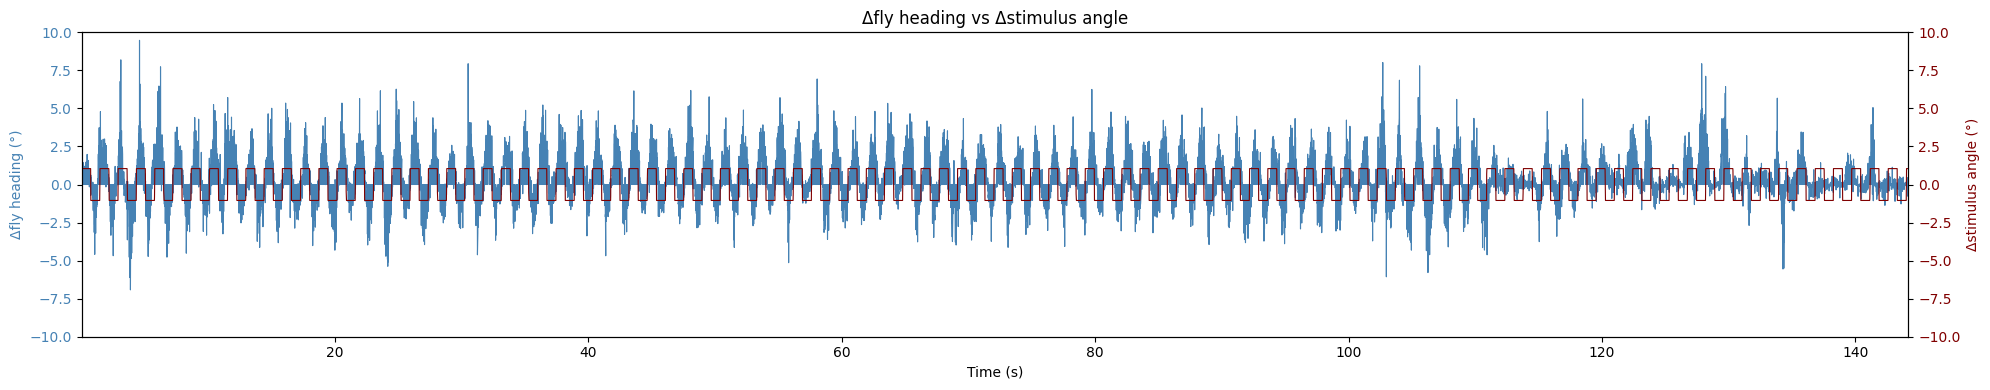

In [43]:

fig, ax1 = plt.subplots(figsize=(20, 4))

# Left Y-axis: Δangle of fly heading
ln1 = ax1.plot(
    plot_time,
    delta_angle_df['delta_angle_fly'],
    label='ΔAngle (Fly)',
    color='steelblue',
    linewidth=0.8
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Δfly heading (°)", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(-10, 10)
ax1.set_xlim([plot_time[0], plot_time[-1]])
ax1.grid(False)

# Right Y-axis: Δangle of stimulus
ax2 = ax1.twinx()

ln2 = ax2.plot(
    plot_time,
    stim_dangle_interp,
    label='Δ stimulus angle',
    color='maroon',
    linewidth=0.8
)
ax2.set_ylabel("Δstimulus angle (°)", color='maroon')
ax2.tick_params(axis='y', labelcolor='maroon')
ax2.set_ylim(-10, 10)

# Optional: Combine legend
# lines = ln1 + ln2
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper right')

ax1.set_title("Δfly heading vs Δstimulus angle")
plt.tight_layout()
plt.show()

### Histogram of the data

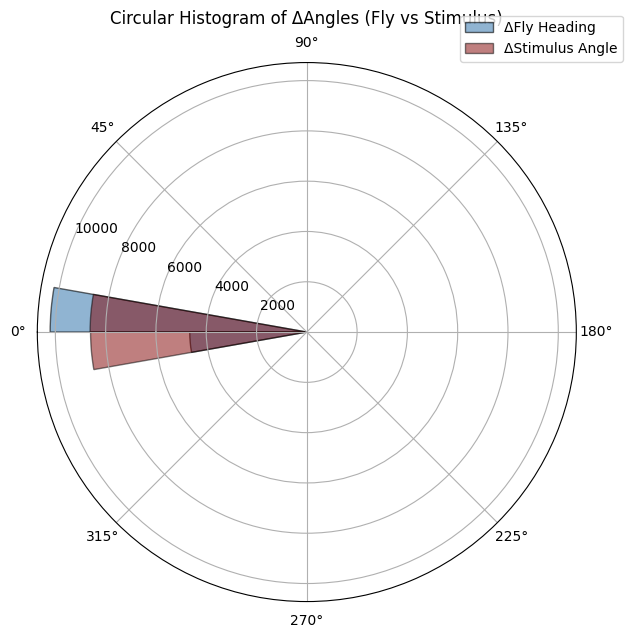

In [49]:
# --- Normalize angles to [-180, 180) and convert to radians
def normalize_angle_deg(angle):
    return ((angle + 180) % 360) - 180

# Fly Δangle
fly_dangle_deg = normalize_angle_deg(delta_angle_df['delta_angle_fly'].to_numpy())
fly_dangle_rad = np.deg2rad(fly_dangle_deg)

# Stimulus Δangle
stim_dangle_deg = normalize_angle_deg(delta_angle_stim_df['delta_angle_stim'].to_numpy())
stim_dangle_rad = np.deg2rad(stim_dangle_deg)

# --- Histogram setup
num_bins = 36  # 10° per bin
bin_edges = np.linspace(-np.pi, np.pi, num_bins + 1)

fly_hist, _ = np.histogram(fly_dangle_rad, bins=bin_edges)
stim_hist, _ = np.histogram(stim_dangle_rad, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_width = (2 * np.pi) / num_bins

# --- Plot: Overlaid Circular Histogram
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Orient plot: 0° = left (West), clockwise
ax.set_theta_zero_location('W')
ax.set_theta_direction(-1)

# Plot Δfly heading histogram
ax.bar(
    bin_centers,
    fly_hist,
    width=bar_width,
    align='center',
    alpha=0.6,
    label='ΔFly Heading',
    color='steelblue',
    edgecolor='black'
)

# Plot Δstimulus angle histogram
ax.bar(
    bin_centers,
    stim_hist,
    width=bar_width,
    align='center',
    alpha=0.5,
    label='ΔStimulus Angle',
    color='maroon',
    edgecolor='black'
)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
ax.set_title("Circular Histogram of ΔAngles (Fly vs Stimulus)", va='bottom')

plt.show()

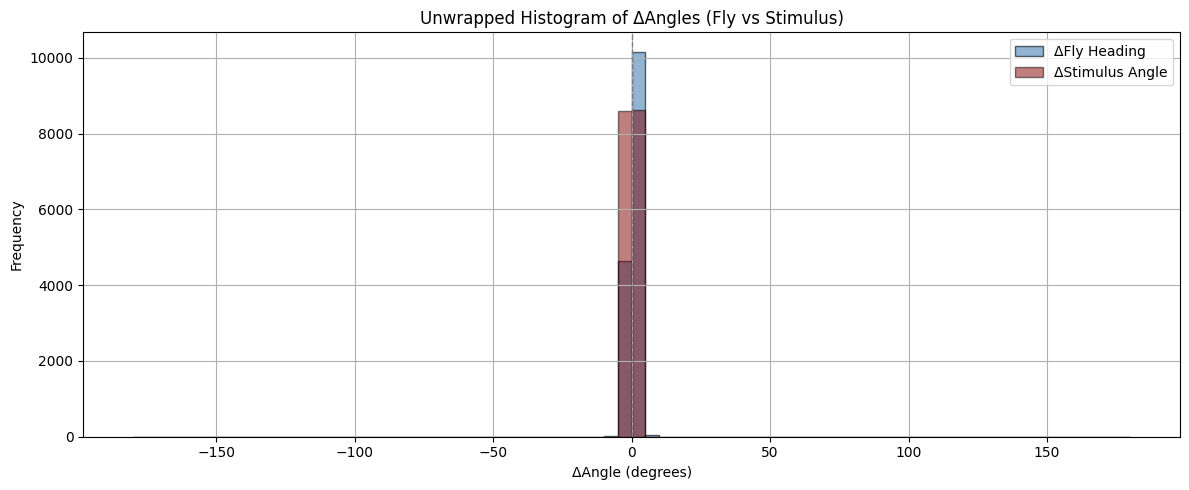

In [50]:
# --- Normalize Δangles to [-180, 180)
def normalize_angle_deg(angle):
    return ((angle + 180) % 360) - 180

# Convert to degrees
fly_dangle_deg = normalize_angle_deg(delta_angle_df['delta_angle_fly'].to_numpy())
stim_dangle_deg = normalize_angle_deg(delta_angle_stim_df['delta_angle_stim'].to_numpy())

# --- Histogram setup
num_bins = 72  # 5° per bin for good resolution
bin_range = (-180, 180)

# Histogram for fly Δangle
fly_hist, bins = np.histogram(fly_dangle_deg, bins=num_bins, range=bin_range)
stim_hist, _    = np.histogram(stim_dangle_deg, bins=bins)

bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]

# --- Plot
plt.figure(figsize=(12, 5))

plt.bar(
    bin_centers,
    fly_hist,
    width=bar_width,
    alpha=0.6,
    label='ΔFly Heading',
    color='steelblue',
    edgecolor='black'
)

plt.bar(
    bin_centers,
    stim_hist,
    width=bar_width,
    alpha=0.5,
    label='ΔStimulus Angle',
    color='maroon',
    edgecolor='black'
)

plt.axvline(0, color='gray', linestyle='--', linewidth=1)  # Center line at 0°
plt.xlabel("ΔAngle (degrees)")
plt.ylabel("Frequency")
plt.title("Unwrapped Histogram of ΔAngles (Fly vs Stimulus)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

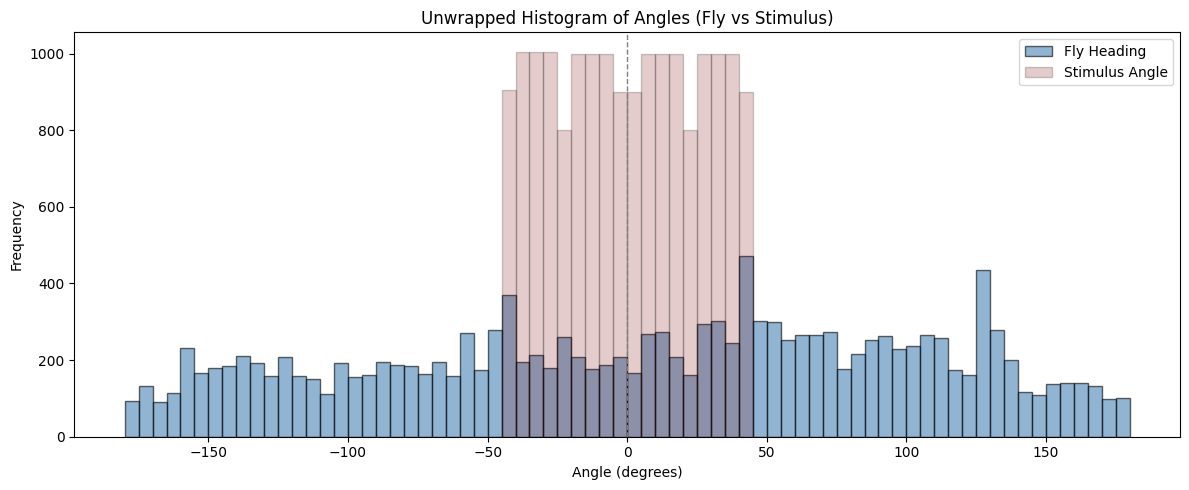

In [51]:
# Normalize angles to [-180, 180)
def normalize_angle_deg(angle):
    return ((angle + 180) % 360) - 180

# Fly angle
fly_angle_deg = normalize_angle_deg(posDf['angle'].to_numpy())

# Stimulus angle (repeated and interpolated)
stim_angle_deg = normalize_angle_deg(
    np.array([float(a) for a in repeated_df['angular_shift (deg)']])
)

# Histogram parameters
num_bins = 72  # 5° per bin
bin_range = (-180, 180)

# Histograms
fly_hist, bins = np.histogram(fly_angle_deg, bins=num_bins, range=bin_range)
stim_hist, _ = np.histogram(stim_angle_deg, bins=bins)

bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]

# Plot
plt.figure(figsize=(12, 5))

plt.bar(
    bin_centers,
    fly_hist,
    width=bar_width,
    alpha=0.6,
    label='Fly Heading',
    color='steelblue',
    edgecolor='black'
)

plt.bar(
    bin_centers,
    stim_hist,
    width=bar_width,
    alpha=0.2,
    label='Stimulus Angle',
    color='maroon',
    edgecolor='black'
)

plt.axvline(0, color='gray', linestyle='--', linewidth=1)  # Center at 0°
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")
plt.title("Unwrapped Histogram of Angles (Fly vs Stimulus)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


### Time intervals for right and left sweep for stimulus

In [41]:
# Step 1: Convert time and angle columns to float (for computation)
stim_time = repeated_df['time [s]'].astype(float).to_numpy()
stim_angle = repeated_df['angular_shift (deg)'].astype(float).to_numpy()

# Step 2: Compute derivative to detect direction
d_angle = np.diff(stim_angle)
d_time = np.diff(stim_time)

# Prevent division by zero (in case of very small dt)
d_time[d_time == 0] = 1e-10

velocity = d_angle / d_time  # degrees per second

# Step 3: Determine direction at each time point
# We'll label "right" as +1, "left" as -1
direction_flag = np.sign(velocity)

# Step 4: Find change points in direction
# Include first index
change_points = [0]
for i in range(1, len(direction_flag)):
    if direction_flag[i] != direction_flag[i - 1]:
        change_points.append(i)

# Include last index
change_points.append(len(stim_time) - 1)

# Step 5: Build interval list
sweep_intervals = []
for i in range(len(change_points) - 1):
    start_idx = change_points[i]
    end_idx = change_points[i + 1]
    if end_idx > start_idx:
        start_time = stim_time[start_idx]
        end_time = stim_time[end_idx]
        start_angle = stim_angle[start_idx]
        end_angle = stim_angle[end_idx]

        if end_angle > start_angle:
            direction = 'right'
        elif end_angle < start_angle:
            direction = 'left'
        else:
            continue  # skip flat segments

        sweep_intervals.append({
            'start_time': start_time,
            'end_time': end_time,
            'direction': direction
        })

# Step 6: Convert to DataFrame
sweep_df = pd.DataFrame(sweep_intervals)

In [42]:
sweep_df.head()

,start_time,end_time,direction
0,0.00,0.72,right
1,0.72,1.44,left
2,1.44,2.16,right
3,2.16,2.88,left
4,2.88,3.60,right


In [43]:
fly_time = posDf['time'].astype(float).to_numpy()
fly_heading = normalized_angle.astype(float).to_numpy()

fly_turning_intervals = []

for _, row in sweep_df.iterrows():
    start = row['start_time']
    end = row['end_time']
    stim_dir = row['direction']

    # Mask for this interval
    mask = (fly_time >= start) & (fly_time <= end)
    t_interval = fly_time[mask]
    h_interval = fly_heading[mask]

    if len(h_interval) < 2:
        fly_turn = 'none'
        delta_heading = np.nan
    else:
        delta_heading = h_interval[-1] - h_interval[0]

        if delta_heading > 20:        # threshold to ignore noise
            fly_turn = 'right'
        elif delta_heading < -20:
            fly_turn = 'left'
        else:
            fly_turn = 'none'

    fly_turning_intervals.append({
        'start_time': start,
        'end_time': end,
        'stimulus_direction': stim_dir,
        'fly_turn_direction': fly_turn,
        'heading_change': delta_heading,
        'n_samples': len(h_interval)
    })

fly_turn_df = pd.DataFrame(fly_turning_intervals)
fly_turn_df.head()

,start_time,end_time,stimulus_direction,fly_turn_direction,heading_change,n_samples
0,0.00,0.72,right,none,6.600952,83
1,0.72,1.44,left,none,4.817352,80
2,1.44,2.16,right,none,-0.708679,86
3,2.16,2.88,left,none,0.567688,81
4,2.88,3.60,right,none,-0.150940,78


In [44]:
fly_turn_df['match'] = fly_turn_df['stimulus_direction'] == fly_turn_df['fly_turn_direction']
accuracy = fly_turn_df['match'].mean()  # fraction of matched turns
accuracy

0.04477611940298507

In [45]:
# Step 1: Convert stimulus time and angle to float arrays
stim_time = repeated_df['time [s]'].astype(float).to_numpy()
stim_angle = repeated_df['angular_shift (deg)'].astype(float).to_numpy()

# Step 2: Create interpolator
from scipy.interpolate import interp1d

stim_interp = interp1d(stim_time, stim_angle, bounds_error=False, fill_value="extrapolate")

# Step 3: Compute stimulus angle change for each sweep
stim_changes = []
for _, row in fly_turn_df.iterrows():
    angle_start = stim_interp(row['start_time'])
    angle_end = stim_interp(row['end_time'])
    stim_changes.append(angle_end - angle_start)

# Step 4: Add to dataframe
fly_turn_df['stimulus_angle_change'] = stim_changes
fly_turn_df.head()


,start_time,end_time,stimulus_direction,fly_turn_direction,heading_change,n_samples,match,stimulus_angle_change
0,0.00,0.72,right,none,6.600952,83,False,90.0
1,0.72,1.44,left,none,4.817352,80,False,-90.0
2,1.44,2.16,right,none,-0.708679,86,False,90.0
3,2.16,2.88,left,none,0.567688,81,False,-90.0
4,2.88,3.60,right,none,-0.150940,78,False,90.0


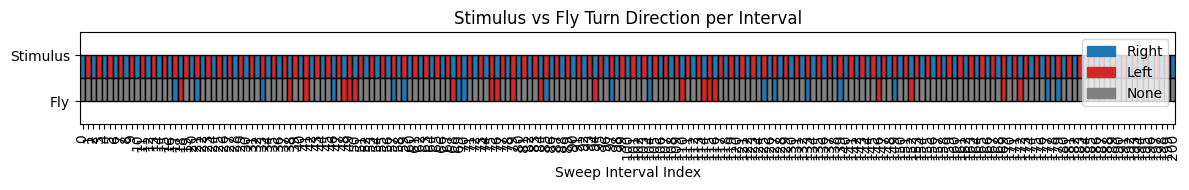

In [46]:

import matplotlib.patches as mpatches

# Map directions to color
color_map = {
    'right': 'tab:blue',
    'left': 'tab:red',
    'none': 'gray'
}

n_intervals = len(fly_turn_df)
x = np.arange(n_intervals)

# Set up plot
fig, ax = plt.subplots(figsize=(12, 2))
bar_height = 0.4

# Plot stimulus direction bars (upper row)
stim_colors = [color_map[d] for d in fly_turn_df['stimulus_direction']]
ax.bar(x, [1]*n_intervals, width=1.0, color=stim_colors, edgecolor='black', align='center', label='Stimulus')

# Plot fly direction bars (lower row)
fly_colors = [color_map[d] for d in fly_turn_df['fly_turn_direction']]
ax.bar(x, [-1]*n_intervals, width=1.0, color=fly_colors, edgecolor='black', align='center', label='Fly')

# Format axis
ax.set_yticks([1, -1])
ax.set_yticklabels(['Stimulus', 'Fly'])
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in x], rotation=90)
ax.set_xlabel('Sweep Interval Index')
ax.set_title('Stimulus vs Fly Turn Direction per Interval')
ax.set_xlim(-0.5, n_intervals - 0.5)
ax.set_ylim(-2, 2)
ax.grid(False)

# Add legend
patches = [
    mpatches.Patch(color='tab:blue', label='Right'),
    mpatches.Patch(color='tab:red', label='Left'),
    mpatches.Patch(color='gray', label='None')
]
ax.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:

# Encode directions as integers
dir_to_int = {'left': -1, 'none': 0, 'right': 1}
stim_dir_encoded = [dir_to_int[d] for d in fly_turn_df['stimulus_direction']]
fly_dir_encoded = [dir_to_int[d] for d in fly_turn_df['fly_turn_direction']]

# Stack into 2D array
data = np.vstack([stim_dir_encoded, fly_dir_encoded])

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 2))
im = ax.imshow(data, aspect='auto', cmap='bwr', vmin=-1, vmax=1)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Stimulus', 'Fly'])
ax.set_xticks([])
ax.set_title('Stimulus vs Fly Turn Direction (Heatmap View)')

plt.colorbar(im, ax=ax, label='Direction (Left ↔ Right)', ticks=[-1, 0, 1])
plt.tight_layout()
plt.show()


In [ ]:


# Extract from DataFrame
stim_angle_change = fly_turn_df['stimulus_angle_change'].to_numpy()
heading_change = fly_turn_df['heading_change'].to_numpy()

# Determine shared max magnitude across both rows
shared_max = max(np.abs(stim_angle_change).max(), np.abs(heading_change).max())

# Normalize to [-1, 1]
stim_normalized = stim_angle_change / shared_max
fly_normalized = heading_change / shared_max

# Stack into heatmap
heatmap_data = np.vstack([stim_normalized, fly_normalized])

# Plot
fig, ax = plt.subplots(figsize=(12, 2))
im = ax.imshow(heatmap_data, aspect='auto', cmap='bwr', vmin=-1, vmax=1)

# Axis settings
ax.set_yticks([0, 1])
ax.set_yticklabels(['Stimulus', 'Fly'])
ax.set_xticks([])
# ax.set_title('Turn Direction & Strength (Normalized to Shared Max)')

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='Normalized Turn Change')
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['Left', '0', 'Right'])

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import correlate

# Step 1: Extract time and angle data
stim_time = repeated_df['time [s]'].astype(float).to_numpy()
stim_angle = repeated_df['angular_shift (deg)'].astype(float).to_numpy()

fly_time = posDf['time'].astype(float).to_numpy()
fly_heading = normalized_angle.astype(float).to_numpy()

# Step 2: Define common time base
dt = 0.01  # 100 Hz sampling
common_time = np.arange(
    max(fly_time.min(), stim_time.min()),
    min(fly_time.max(), stim_time.max()),
    dt
)

# Step 3: Interpolate both signals
stim_interp = interp1d(stim_time, stim_angle, bounds_error=False, fill_value="extrapolate")
fly_interp = interp1d(fly_time, fly_heading, bounds_error=False, fill_value="extrapolate")

stim_uniform = stim_interp(common_time)
fly_uniform = fly_interp(common_time)

# Step 4: Z-score both signals (mean=0, std=1)
stim_z = (stim_uniform - np.nanmean(stim_uniform)) / np.nanstd(stim_uniform)
fly_z = (fly_uniform - np.nanmean(fly_uniform)) / np.nanstd(fly_uniform)

# Step 5: Compute cross-correlation
corr = correlate(fly_z, stim_z, mode='full')
lags = np.arange(-len(fly_z) + 1, len(fly_z)) * dt

# Normalize correlation
corr = corr / len(fly_z)

# Step 6: Plot
plt.figure(figsize=(10, 4))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title('Cross-Correlation between Stimulus and Fly Heading')
plt.xlabel('Lag (seconds)')
plt.ylabel('Correlation coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
fly_velocity = np.gradient(fly_uniform, dt)


In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

fs = 1 / dt  # Sampling rate (Hz)
stim_filtered = bandpass_filter(stim_z, 0.2, 2.0, fs)
fly_filtered = bandpass_filter(fly_velocity, 0.2, 2.0, fs)


In [ ]:
max_lag_seconds = 10
max_lag_samples = int(max_lag_seconds / dt)

corr = correlate(fly_filtered, stim_filtered, mode='full') / len(fly_filtered)
lags = np.arange(-len(fly_filtered) + 1, len(fly_filtered)) * dt
center = len(corr) // 2
corr = corr[center - max_lag_samples : center + max_lag_samples]
lags = lags[center - max_lag_samples : center + max_lag_samples]


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title('Filtered Cross-Correlation (Stimulus vs. Fly Turn Rate)')
plt.xlabel('Lag (seconds)')
plt.ylabel('Correlation Coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
fly_turn_df['stimulus_direction']  # 'left' or 'right'
fly_turn_df['heading_change']      # degrees change


In [ ]:
def classify_behavior(row, threshold=5):
    delta = row['heading_change']
    stim_dir = row['stimulus_direction']
    
    if abs(delta) < threshold:
        return 'neutral'
    elif (stim_dir == 'right' and delta > threshold) or (stim_dir == 'left' and delta < -threshold):
        return 'tracking'
    else:
        return 'anti-tracking'

fly_turn_df['tracking_category'] = fly_turn_df.apply(classify_behavior, axis=1)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assign colors to categories
color_map = {'tracking': 'green', 'neutral': 'gray', 'anti-tracking': 'red'}
colors = fly_turn_df['tracking_category'].map(color_map)

# Plot behavior over time
plt.figure(figsize=(12, 1.5))
plt.bar(range(len(fly_turn_df)), [1]*len(fly_turn_df), color=colors, edgecolor='k', linewidth=0.2)
plt.xticks([])
plt.yticks([])
plt.title("Fly Tracking Behavior per Stimulus Sweep")
plt.xlabel("Sweep #")
plt.legend(handles=[
    plt.Line2D([0], [0], color='green', lw=6, label='Tracking'),
    plt.Line2D([0], [0], color='gray', lw=6, label='Neutral'),
    plt.Line2D([0], [0], color='red', lw=6, label='Anti-tracking')
])
plt.tight_layout()
plt.show()


In [ ]:
fly_turn_df['tracking_category'].value_counts(normalize=True)


In [ ]:
from scipy.signal import correlate
from scipy.interpolate import interp1d

def get_crosscorr_segments(df, category, stim_time, stim_angle, fly_time, fly_heading, dt=0.01):
    # Interpolators
    stim_interp = interp1d(stim_time, stim_angle, bounds_error=False, fill_value="extrapolate")
    fly_interp = interp1d(fly_time, fly_heading, bounds_error=False, fill_value="extrapolate")

    aligned_stim = []
    aligned_fly = []

    for _, row in df[df['tracking_category'] == category].iterrows():
        t0, t1 = row['start_time'], row['end_time']
        t_segment = np.arange(t0, t1, dt)
        
        if len(t_segment) < 2:
            continue

        stim_seg = stim_interp(t_segment)
        fly_seg = fly_interp(t_segment)
        fly_vel = np.gradient(fly_seg, dt)

        # Z-score
        stim_seg = (stim_seg - np.mean(stim_seg)) / np.std(stim_seg)
        fly_vel = (fly_vel - np.mean(fly_vel)) / np.std(fly_vel)

        aligned_stim.append(stim_seg)
        aligned_fly.append(fly_vel)

    # Pad to same length (min length across all segments)
    min_len = min(map(len, aligned_stim))
    aligned_stim = np.array([s[:min_len] for s in aligned_stim])
    aligned_fly = np.array([f[:min_len] for f in aligned_fly])

    # Average across sweeps
    stim_avg = np.mean(aligned_stim, axis=0)
    fly_avg = np.mean(aligned_fly, axis=0)

    # Cross-correlation
    corr = correlate(fly_avg, stim_avg, mode='full')
    lags = np.arange(-len(stim_avg) + 1, len(stim_avg)) * dt
    corr /= len(stim_avg)  # Normalize

    return lags, corr


In [ ]:
# Compute
lags_track, corr_track = get_crosscorr_segments(fly_turn_df, 'tracking', stim_time, stim_angle, fly_time, fly_heading)
lags_anti, corr_anti = get_crosscorr_segments(fly_turn_df, 'anti-tracking', stim_time, stim_angle, fly_time, fly_heading)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(lags_track, corr_track, label='Tracking', color='green')
plt.plot(lags_anti, corr_anti, label='Anti-tracking', color='red')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Lag (seconds)')
plt.ylabel('Cross-Correlation')
plt.title('Stimulus-Fly Turn Cross-Correlation by Behavior')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
